# Phase 1: Exploratory Data Analysis (EDA)

This notebook explores the IBM AMLSim HI-Small dataset to understand class balance, transaction distributions, and temporal patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add src to path
sys.path.append(os.path.abspath('..'))

from src.pipeline.data_ingestion import load_ibm_pipeline, get_summary_stats, generate_synthetic_data

sns.set_theme(style="whitegrid")

## 1. Load Data

In [2]:
DATA_PATH = "../data/raw/HI-Small_Trans.csv"

if os.path.exists(DATA_PATH):
    df = load_ibm_pipeline(DATA_PATH)
else:
    print("Raw data not found. Using synthetic data for demo.")
    synthetic_raw = generate_synthetic_data(10000)
    # Use a dummy path for generate_synthetic_data context if needed, but here we can just use the DF
    # For consistency with the requested sections, let's normalize/clean a synthetic DF
    from src.pipeline.data_ingestion import normalize_ibm_amlsim, load_and_clean
    # mock saving to load via pipeline
    synthetic_raw.to_csv("temp_eda.csv", index=False)
    df = load_ibm_pipeline("temp_eda.csv")
    os.remove("temp_eda.csv")

print(f"Loaded {len(df)} transactions.")
df.head()

2026-04-25 11:36:11,224 - INFO - Normalizing IBM AMLSim data from ../data/raw/HI-Small_Trans.csv


2026-04-25 11:36:27,381 - INFO - Cleaning and engineering features for normalized data


2026-04-25 11:36:28,668 - WARNING - Dropped 591212 self-transfers


2026-04-25 11:36:32,776 - WARNING - Dropped 119774 rows with unknown transaction types


Loaded 4367359 transactions.


,transaction_id,timestamp,sender_id,receiver_id,amount,transaction_type,sender_country,receiver_country,is_laundering,hour_of_day,day_of_week,is_cross_border,amount_log
0,TXN_000001,2022-09-01 00:20:00,8000F4580,8000F5340,0.01,ACH,US Dollar,US Dollar,0,0,3,False,0.009950
1,TXN_000008,2022-09-01 00:26:00,8000EC280,8017BF800,7.66,ACH,US Dollar,US Dollar,0,0,3,False,2.158715
2,TXN_000009,2022-09-01 00:21:00,8000EDEC0,80AEF5310,383.71,ACH,US Dollar,US Dollar,0,0,3,False,5.952490
3,TXN_000010,2022-09-01 00:04:00,8000F4510,8011305D0,9.82,ACH,US Dollar,US Dollar,0,0,3,False,2.381396
4,TXN_000012,2022-09-01 00:08:00,8000F4FE0,812ED62E0,4.01,ACH,US Dollar,US Dollar,0,0,3,False,1.611436


## 2. Summary Statistics

In [3]:
stats = get_summary_stats(df)
for k, v in stats.items():
    print(f"{k}: {v}")

total_transactions: 4367359
laundering_count: 5110
laundering_rate: 0.0011700434976836115
transaction_type_breakdown: {'ACH': 3706863, 'CASH': 489436, 'WIRE': 171060}
cross_border_count: 2191
cross_border_rate: 0.0005016761846232472
amount_mean: 4906381.5258778315
amount_std: 937435357.7116436
amount_median: 1554.94


## 3. Class Imbalance

2026-04-25 11:36:36,658 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-04-25 11:36:36,665 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


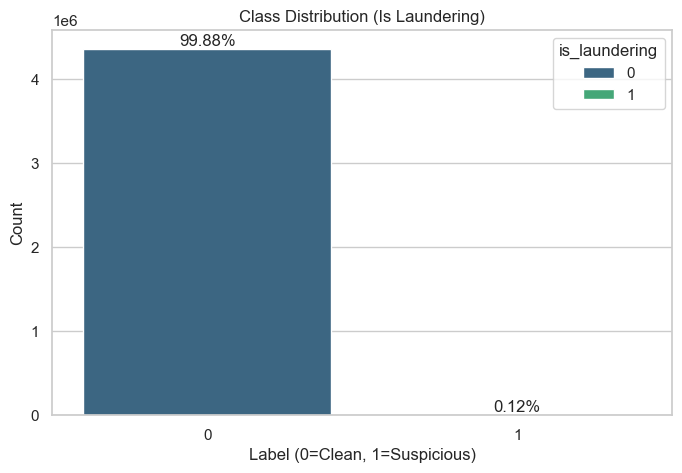

In [4]:
plt.figure(figsize=(8, 5))
counts = df['is_laundering'].value_counts()
pcts = df['is_laundering'].value_counts(normalize=True) * 100

sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis")
plt.title("Class Distribution (Is Laundering)")
plt.xlabel("Label (0=Clean, 1=Suspicious)")
plt.ylabel("Count")

for i, p in enumerate(counts.index):
    plt.text(i, counts[p], f"{pcts[p]:.2f}%", ha='center', va='bottom')
plt.show()

## 4. Amount Distribution

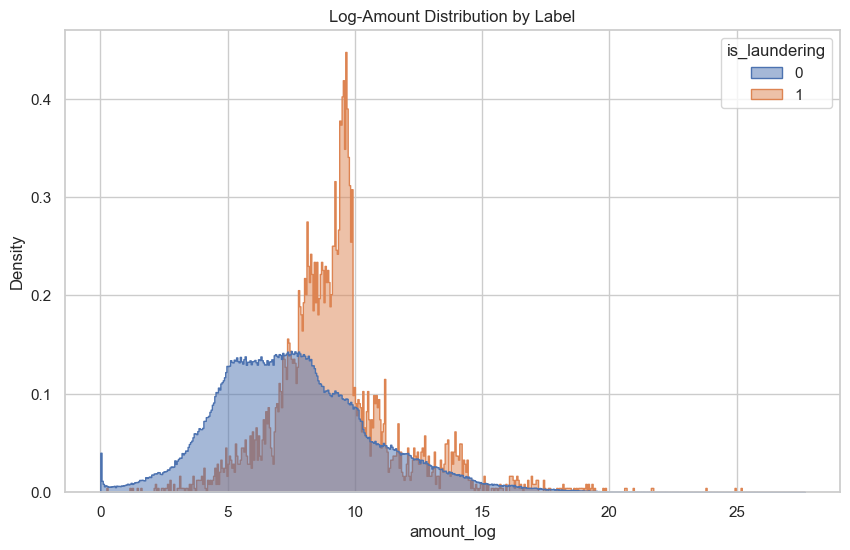

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='amount_log', hue='is_laundering', element="step", stat="density", common_norm=False, alpha=0.5)
plt.title("Log-Amount Distribution by Label")
plt.show()

## 5. Transaction Type Breakdown

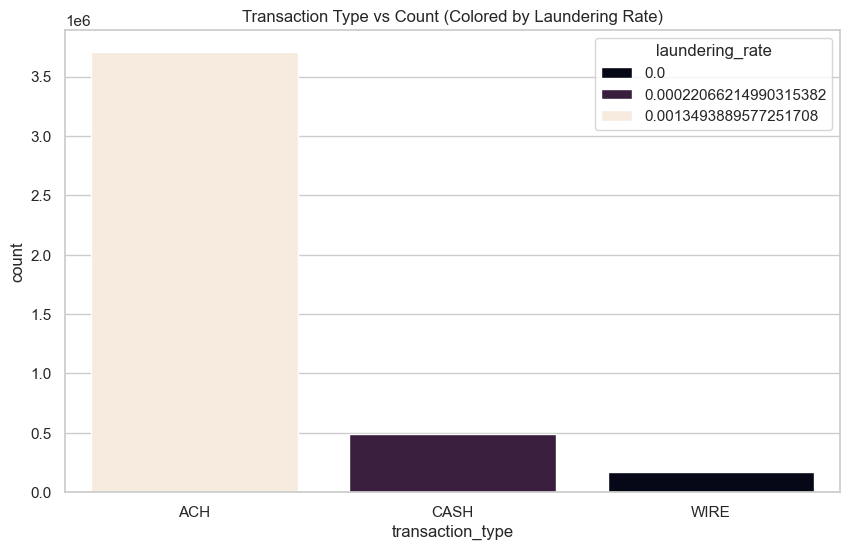

In [6]:
type_stats = df.groupby('transaction_type')['is_laundering'].agg(['count', 'mean']).reset_index()
type_stats.rename(columns={'mean': 'laundering_rate'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=type_stats, x='transaction_type', y='count', hue='laundering_rate', palette="rocket")
plt.title("Transaction Type vs Count (Colored by Laundering Rate)")
plt.show()

## 6. Hour of Day

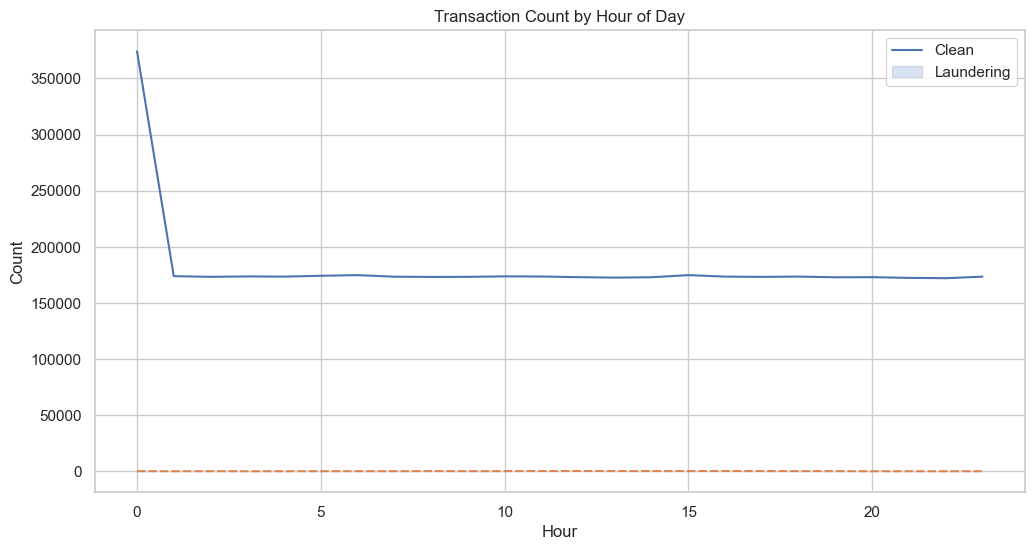

In [7]:
plt.figure(figsize=(12, 6))
hour_counts = df.groupby(['hour_of_day', 'is_laundering']).size().unstack(fill_value=0)
sns.lineplot(data=hour_counts)
plt.title("Transaction Count by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.legend(["Clean", "Laundering"])
plt.show()

## 7. Cross-Border Analysis

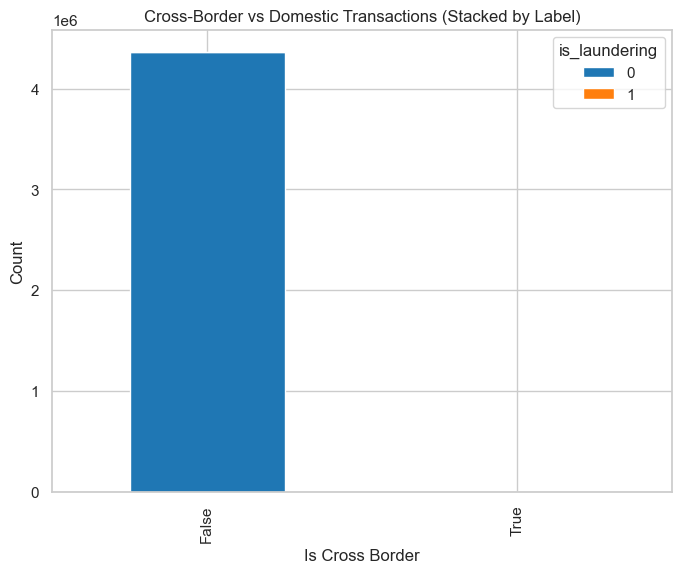

In [8]:
plt.figure(figsize=(8, 6))
cb_counts = df.groupby(['is_cross_border', 'is_laundering']).size().unstack(fill_value=0)
cb_counts.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], ax=plt.gca())
plt.title("Cross-Border vs Domestic Transactions (Stacked by Label)")
plt.xlabel("Is Cross Border")
plt.ylabel("Count")
plt.show()

## 8. Payment Currency Distribution

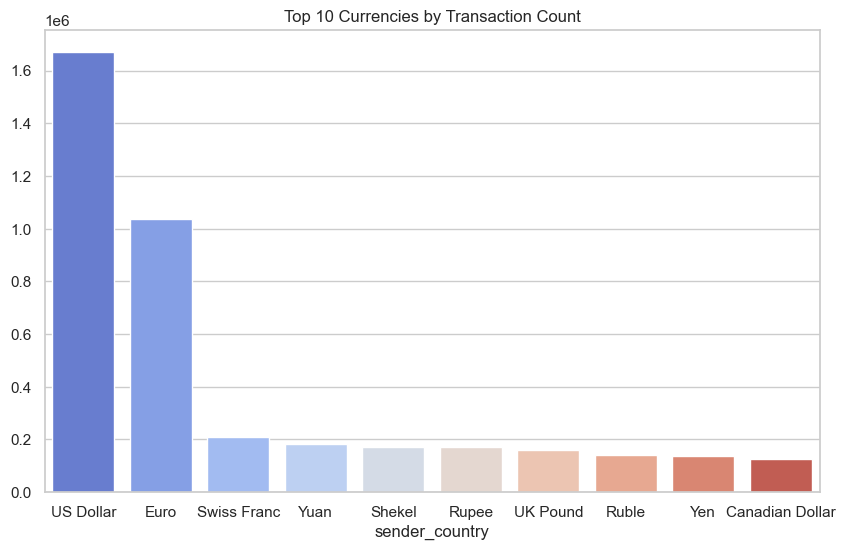

In [9]:
plt.figure(figsize=(10, 6))
top_currencies = df['sender_country'].value_counts().head(10)
sns.barplot(x=top_currencies.index, y=top_currencies.values, hue=top_currencies.index, palette="coolwarm")
plt.title("Top 10 Currencies by Transaction Count")
plt.show()